# BLIP（Bootstrapping Language-Image Pre-training）模型

> **论文**：*BLIP: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation*（Li et al., ICML 2022）  
> **核心创新**：提出 MED（Multimodal mixture of Encoder-Decoder）统一架构，同时支持图文理解与生成；引入 CapFilt 机制（Captioner + Filter）对网络噪声图文对自举式清洗，大幅提升预训练数据质量。  
> **三大训练任务**：ITC（图文对比）+ ITM（图文匹配）+ LM（语言模型，自回归生成）

## 一、BLIP 多模态编码-解码模型核心架构（手动搭建）

本节手动搭建简化版 BLIP-MED（Multimodal mixture of Encoder-Decoder）模型，包含以下子模块：
- `ViTModel`：预训练 ViT-Base/16 图像编码器（将 224×224 图像切分为 196 个 patch + [CLS]，共 197 个 token，每位特征维度 768）
- `BertModel`（文本编码器模式）：12 层双向 BERT-base，对输入文本进行上下文语义编码
- `ITC 头`：图像-文本对比学习投影头（Linear + LayerNorm），将模态特征映射到共享嵌入空间
- `ITM 头`：图像-文本匹配二分类线性头，输出匹配/不匹配的 logits
- `ImageGroundedTextDecoder` + `LM 头`：以图像特征为 Key/Value 条件的 Transformer 自回归解码器，用于文本生成

In [ ]:
import torch  # 导入PyTorch库
import torch.nn as nn  # 导入PyTorch神经网络模块
import torch.nn.functional as F  # 导入函数式API：cross_entropy、normalize 等
from transformers import BertModel, ViTModel, BertTokenizer  # 从transformers库导入预训练模型和分词器

class BLIP_MED(nn.Module):  # 定义BLIP多模态编码解码模型
    """
    BLIP 多模态编码-解码（Multimodality Encoder-Decoder）统一模型。

    将 ViT 图像编码器、BERT 文本编码器整合为支持三大预训练任务的统一架构：
    - ITC（Image-Text Contrastive）：图像-文本对比学习，拉近匹配对的特征距离
    - ITM（Image-Text Matching）：二分类判断图文是否匹配
    - LM（Language Modeling）：以图像特征为条件的自回归文本生成

    Attributes:
        image_encoder (ViTModel): 预训练 ViT-Base/16 图像编码器，将 224×224 图像切分为
            196 个 16×16 patch，加上 [CLS] token 共 197 个位置，每位特征维度 768
        text_encoder (BertModel): 预训练 BERT-base-uncased 双向文本编码器，
            输出每个 token 的上下文语义向量，[CLS] 位置的特征代表全句语义
        image_proj (nn.Linear): 图像 ITC 投影头，将 768 维图像 [CLS] 特征线性投影到 256 维嵌入空间
        text_proj (nn.Linear): 文本 ITC 投影头，将 768 维文本 [CLS] 特征线性投影到 256 维嵌入空间
        temp (nn.Parameter): 可学习温度系数（标量），初始值 0.07，控制 InfoNCE 相似度分布的尖锐程度
        itm_head (nn.Linear): ITM 二分类头，将 768 维 [CLS] 特征映射为 2 维 logits
            （第0维=不匹配，第1维=匹配）
        lm_head (nn.Linear): LM 预测头，将 768 维隐藏状态映射到 vocab_size 维词表分布
        text_decoder (ImageGroundedTextDecoder): 以图像特征为 Key/Value 的
            Transformer 自回归解码器，生成图像相关文本
    """
    def __init__(self, config):  # 初始化函数，接收配置参数
        """
        初始化 BLIP_MED 的所有子模块。

        Args:
            config (BertConfig): 模型超参数配置对象，常用字段说明：
                - hidden_size (int): 隐藏层维度，BertConfig 默认 768
                - vocab_size (int): 词表大小，BERT-uncased 为 30522
                - num_hidden_layers (int): 解码器层数，BertConfig 默认 12
                - intermediate_size (int): FFN 中间层维度，BertConfig 默认 3072
                - num_attention_heads (int): 多头注意力头数，BertConfig 默认 12
                - max_position_embeddings (int): 位置嵌入最大长度，BertConfig 默认 512
        """
        super().__init__()  # 调用父类初始化
        self.image_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224", cache_dir="./model_cache/ViT")  # 加载预训练的ViT图像编码器
        self.text_encoder = BertModel.from_pretrained("bert-base-uncased", cache_dir="./model_cache/bert")  # 加载预训练的BERT文本编码器
        self.itc_image_proj = nn.Linear(config.hidden_size, 256)  # 图像 ITC 投影头：将 768 维图像 [CLS] 特征投影到 256 维对比嵌入空间
        self.itc_text_proj = nn.Linear(config.hidden_size, 256)   # 文本 ITC 投影头：将 768 维文本 [CLS] 特征投影到 256 维对比嵌入空间
        # 可学习温度系数（标量 nn.Parameter）：除以 temp 可放大/缩小相似度分布；
        # 初始值 0.07 与 BLIP / CLIP 论文保持一致，训练时由优化器自动调整
        self.temp = nn.Parameter(torch.ones([]) * 0.07)
        # ITM 二分类头：输入 hidden_size（768）维特征，输出 2 维 logits（不匹配/匹配）
        self.itm_head = nn.Linear(config.hidden_size, 2)
        # LM 预测头：将 hidden_size（768）维解码器输出映射到词表 vocab_size（30522）维分布
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size)
        self.text_decoder = ImageGroundedTextDecoder(config)  # 初始化基于图像的文本解码器

    def forward(self, image, input_ids, attention_mask, decoder_input_ids=None):  # 前向传播函数
        """
        BLIP_MED 前向传播：依次执行图像编码、文本编码和三大任务头计算。

        Args:
            image (Tensor): 预处理后的图像批次，形状 (batch_size, 3, 224, 224)
                - dim0 batch_size: 批次中图像的数量
                - dim1 3: RGB 三通道
                - dim2/dim3 224: ViT 标准输入分辨率（高 × 宽）
            input_ids (Tensor): 文本 token ID 序列，形状 (batch_size, seq_len)
                - dim0 batch_size: 批次中句子的数量
                - dim1 seq_len: 分词后含 [CLS]/[SEP]/padding 的 token 总数
            attention_mask (Tensor): 文本自注意力掩码，形状 (batch_size, seq_len)；
                有效 token 位置为 1，padding 位置为 0
            decoder_input_ids (Tensor, optional): 解码器输入 token ID，
                形状 (batch_size, dec_len)；为 None 时跳过 LM 分支

        Returns:
            dict: 包含三个任务输出的字典：
                - "itc_loss"   (Tensor): InfoNCE 对称对比损失，标量；
                    由图→文和文→图两个方向的交叉熵损失平均得到，值越小表示批内正样本对越相似
                - "itm_logits" (Tensor): ITM 分类 logits，形状 (batch_size, 2)，
                    dim1 的两个值分别对应「不匹配」和「匹配」两类
                - "lm_logits"  (Tensor | None): LM 词表预测 logits，
                    形状 (batch_size, dec_len, vocab_size)；decoder_input_ids 为 None 时为 None
        """
        # ViT image features
        image_outputs = self.image_encoder(pixel_values=image)  # 通过ViT编码图像
        # 取最后一层所有位置的隐藏状态，形状 (batch_size, 197, 768)
        # - dim0 batch_size: 批次中图像的数量
        # - dim1 197: 196 个图像 patch（14×14 grid）+ 1 个 [CLS] 全局 token = 197
        # - dim2 768: ViT-Base/16 的隐藏层特征维度
        image_feat = image_outputs.last_hidden_state

        # Text encoding
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)  # 通过BERT编码文本
        # 取 BERT 最后一层所有 token 的隐藏状态，形状 (batch_size, seq_len, 768)
        # - dim0 batch_size: 批次中句子的数量
        # - dim1 seq_len: 分词后 token 总数（含 [CLS]、[SEP] 和 padding）
        # - dim2 768: BERT-base 的隐藏层特征维度
        text_feat = text_outputs.last_hidden_state
        # 取 [CLS] token（索引0）的特征作为句子级全局语义表示，形状 (batch_size, 768)
        # - dim0 batch_size: 批次中句子的数量
        # - dim1 768: [CLS] token 的特征维度，融合了整句话的上下文语义
        cls_feat = text_feat[:, 0]
        print(f'cls_feat: {cls_feat.shape}')  # 调试输出：打印 [CLS] 特征形状，验证维度是否为 (batch_size, 768)
        # ITC: use cls_feat and image_feat[CLS]
        # 取图像 [CLS] token（索引0）的特征作为图像级全局表示，形状 (batch_size, 768)
        # - dim0 batch_size: 批次中图像的数量
        # - dim1 768: [CLS] 位置的全局图像语义特征维度
        image_cls = image_feat[:, 0]
        # ---- ITC：InfoNCE 对称对比损失 ----
        # 步骤1：分别经各自投影头线性变换，再 L2 归一化到单位超球面
        # image_emb 形状 (batch_size, 256)：归一化后的图像嵌入向量，每行模长为 1
        # - dim0 batch_size: 批次中图像的数量
        # - dim1 256: ITC 嵌入空间维度（低于 ViT 的 768，压缩语义表示）
        image_emb = F.normalize(self.itc_image_proj(image_cls), dim=-1)
        # text_emb 形状 (batch_size, 256)：归一化后的文本嵌入向量
        # - dim0 batch_size: 批次中文本的数量（与图像一一对应）
        # - dim1 256: ITC 嵌入空间维度
        text_emb = F.normalize(self.itc_text_proj(cls_feat), dim=-1)

        # 步骤2：计算批内所有图文两两组合的余弦相似度矩阵，再除以可学习温度系数
        # sim_i2t 形状 (batch_size, batch_size)：图→文全对相似度矩阵（除以 temp 后的 logits）
        # - sim_i2t[i, j]：第 i 张图像与第 j 段文本的相似度 logit
        # - 对角线 sim_i2t[i, i]：第 i 个正样本对的 logit，训练目标是使其最大
        sim_i2t = image_emb @ text_emb.T / self.temp
        # sim_t2i 形状 (batch_size, batch_size)：文→图全对相似度矩阵（sim_i2t 的转置）
        # - sim_t2i[j, i]：第 j 段文本与第 i 张图像的相似度 logit
        sim_t2i = text_emb @ image_emb.T / self.temp

        # 步骤3：构造对角线标签——第 i 个样本的正样本索引为 i（批内正样本在对角线上）
        # labels 形状 (batch_size,)：整型张量，值为 [0, 1, 2, ..., batch_size-1]
        labels = torch.arange(image_emb.size(0), device=image_emb.device)

        # 步骤4：计算对称 InfoNCE 损失
        # - loss_i2t：以每行图像 logits 为输入，对角线索引为目标，计算多分类交叉熵
        #   含义：对于每张图像，在批内所有文本中找到与之匹配的那一段（即正样本）
        # - loss_t2i：以每行文本 logits 为输入，对角线索引为目标，计算多分类交叉熵
        #   含义：对于每段文本，在批内所有图像中找到与之匹配的那一张（即正样本）
        # - itc_loss：两个方向损失的平均值，标量 Tensor
        loss_i2t = F.cross_entropy(sim_i2t, labels)  # 图→文方向交叉熵损失，标量
        loss_t2i = F.cross_entropy(sim_t2i, labels)  # 文→图方向交叉熵损失，标量
        itc_loss = (loss_i2t + loss_t2i) / 2         # 对称平均，标量

        # ITM,这里是要做交叉注意力后的，不是很准确
        # 将文本 [CLS] 特征送入 ITM 二分类头；输出形状 (batch_size, 2)
        # - dim0 batch_size: 批次中样本的数量
        # - dim1 2: 第0维=「不匹配」logit，第1维=「匹配」logit，softmax 后得到概率
        itm_logits = self.itm_head(cls_feat)

        # LM decoding if decoder_input_ids provided
        if decoder_input_ids is not None:  # 如果提供了解码器输入，执行图像条件下的文本生成
            # text_decoder 输出形状 (batch_size, dec_len, 768)，每个 token 位置的解码器隐藏状态
            lm_outputs = self.text_decoder(decoder_input_ids, image_feat)
            # 经 LM 头线性投影到词表空间；形状 (batch_size, dec_len, vocab_size)
            # - dim0 batch_size: 批次大小
            # - dim1 dec_len: 解码序列的 token 数量
            # - dim2 vocab_size: 词表大小（30522），每位对应该 token 的未归一化得分（logit）
            lm_logits = self.lm_head(lm_outputs)
        else:
            lm_logits = None  # 未提供解码器输入时，LM 输出置 None

        return {  # 返回包含三大任务输出的字典
            "itc_loss": itc_loss,    # InfoNCE 对称对比损失，标量
            "itm_logits": itm_logits, # ITM 匹配 logits，形状 (batch_size, 2)
            "lm_logits": lm_logits    # LM 词表 logits，形状 (batch_size, dec_len, vocab_size) 或 None
        }

class ImageGroundedTextDecoder(nn.Module):  # 定义基于图像的文本解码器
    """
    基于图像特征的自回归文本解码器（Image-Grounded Text Decoder）。

    由多个 TransformerDecoderBlock 堆叠而成，每个 Block 内通过交叉注意力机制
    让文本 Query 能够"看到"图像特征（Key/Value），实现图像条件下的文本生成。
    在生成时使用因果掩码（Causal Mask），保证 token 只能关注其左侧的历史 token。

    Attributes:
        layers (nn.ModuleList): 由 num_hidden_layers 个 TransformerDecoderBlock 构成的解码器层列表
        embedding (nn.Embedding): 词嵌入矩阵，将 token ID（标量）映射为 hidden_size（768）维稠密向量
        position_embedding (nn.Embedding): 位置嵌入矩阵，为序列中每个位置提供位置编码向量
        layernorm (nn.LayerNorm): 对词嵌入与位置嵌入之和做层归一化，稳定训练初期的数值分布
    """
    def __init__(self, config):  # 初始化函数
        """
        初始化 ImageGroundedTextDecoder 的子模块。

        Args:
            config (BertConfig): 模型超参数配置对象，关键字段说明：
                - num_hidden_layers (int): 解码器层数，即堆叠的 TransformerDecoderBlock 数量（默认 12）
                - vocab_size (int): 词表大小，决定 embedding 矩阵的行数（BERT-uncased 为 30522）
                - hidden_size (int): 隐藏层维度，词嵌入和所有隐藏状态的特征维度（默认 768）
                - max_position_embeddings (int): 位置嵌入最大长度，限制输入序列的最大长度（默认 512）
        """
        super().__init__()  # 调用父类初始化
        self.layers = nn.ModuleList([  # 创建 Transformer 解码器层列表（ModuleList 确保子模块被正确注册）
            # 根据 config.num_hidden_layers 创建对应数量的 TransformerDecoderBlock
            TransformerDecoderBlock(config) for _ in range(config.num_hidden_layers)
        ])
        # 词嵌入矩阵：大小 (vocab_size, hidden_size)，将每个 token ID 映射为 768 维向量
        self.embedding = nn.Embedding(config.vocab_size, config.hidden_size)
        # 位置嵌入矩阵：大小 (max_position_embeddings, hidden_size)，为每个位置提供 768 维位置编码
        self.position_embedding = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        # 层归一化：对输入 embedding 的和做归一化，维度 hidden_size（768）
        self.layernorm = nn.LayerNorm(config.hidden_size)

    def forward(self, decoder_input_ids, image_feats):  # 前向传播函数
        """
        ImageGroundedTextDecoder 前向传播：将 token ID 序列解码为图像条件下的上下文隐藏状态。

        Args:
            decoder_input_ids (Tensor): 解码器输入 token ID，形状 (batch_size, dec_len)
                - dim0 batch_size: 批次中句子的数量
                - dim1 dec_len: 解码序列的 token 数量
            image_feats (Tensor): 来自 ViT 编码器的图像特征序列，形状 (batch_size, 197, 768)
                - dim0 batch_size: 批次中图像的数量
                - dim1 197: 196 个图像 patch + 1 个 [CLS] token，作为交叉注意力的 Key/Value
                - dim2 768: ViT-Base 的隐藏层特征维度

        Returns:
            Tensor: 每个解码 token 的最终隐藏状态，形状 (batch_size, dec_len, hidden_size)
                - dim0 batch_size: 批次中句子的数量
                - dim1 dec_len: 解码序列长度，与输入 decoder_input_ids 相同
                - dim2 hidden_size=768: 解码器隐藏层维度，后续送入 lm_head 映射到词表
        """
        bsz, seq_len = decoder_input_ids.shape  # 获取批次大小（bsz）和解码序列长度（seq_len）
        # 生成位置索引序列 [0, 1, 2, ..., seq_len-1]，形状 (seq_len,)
        # dtype=torch.long：位置索引为整型，用于查找位置嵌入矩阵
        pos_ids = torch.arange(0, seq_len, dtype=torch.long, device=decoder_input_ids.device)
        # 在第0维添加 batch 维度后广播展开，形状从 (seq_len,) → (batch_size, seq_len)
        # 每行均为 [0, 1, 2, ..., seq_len-1]，与 decoder_input_ids 的形状完全一致
        pos_ids = pos_ids.unsqueeze(0).expand_as(decoder_input_ids)

        # 词嵌入 + 位置嵌入叠加，形状 (batch_size, dec_len, hidden_size=768)
        # 词嵌入捕获 token 的语义信息，位置嵌入提供序列中的相对位置信息
        x = self.embedding(decoder_input_ids) + self.position_embedding(pos_ids)
        # 对嵌入结果做层归一化，稳定训练初期数值分布；形状不变 (batch_size, dec_len, 768)
        x = self.layernorm(x)

        for layer in self.layers:  # 遍历所有解码器层（共 num_hidden_layers 个 TransformerDecoderBlock）
            # 每层经过因果自注意力 + 图文交叉注意力 + FFN 后更新特征；形状不变 (batch_size, dec_len, 768)
            x = layer(x, image_feats)

        # 返回所有解码 token 的最终隐藏状态，形状 (batch_size, dec_len, hidden_size=768)
        return x

class TransformerDecoderBlock(nn.Module):  # 定义Transformer解码器块
    """
    Transformer 解码器单元块（Decoder Block）。

    由三个子模块依次串联构成，每个子模块后均接残差连接和层归一化：
    1. 带因果掩码的自注意力（Causal Self-Attention）：
       Q=K=V=解码特征，上三角掩码确保 token 只能关注左侧历史 token
    2. 交叉注意力（Cross-Attention）：
       Q=解码特征，K=V=图像 patch 特征序列，让文本"感知"图像内容
    3. 前馈神经网络（FFN）：
       两层线性变换（hidden_size→intermediate_size→hidden_size），中间使用 GELU 激活

    Attributes:
        self_attn  (nn.MultiheadAttention): 多头因果自注意力，batch_first=True 要求输入
            形状为 (batch, seq, dim) 而非 PyTorch 默认的 (seq, batch, dim)
        cross_attn (nn.MultiheadAttention): 多头交叉注意力，Query 来自文本，Key/Value 来自图像
        feed_forward (nn.Sequential): FFN，升维 (hidden→intermediate) + GELU + 降维 (intermediate→hidden)
        norm1/norm2/norm3 (nn.LayerNorm): 分别用于自注意力、交叉注意力、FFN 之后的层归一化
    """
    def __init__(self, config):  # 初始化函数
        """
        初始化 TransformerDecoderBlock 的所有子模块。

        Args:
            config (BertConfig): 模型超参数配置对象，关键字段说明：
                - hidden_size (int): Q/K/V 向量维度及 FFN 输入/输出维度，默认 768
                - num_attention_heads (int): 多头注意力的头数，默认 12；
                    要求 hidden_size（768）能被 num_attention_heads（12）整除
                - intermediate_size (int): FFN 中间层升维宽度，默认 3072（= 4 × hidden_size）
        """
        super().__init__()  # 调用父类初始化
        # 因果多头自注意力：embed_dim=768，num_heads=12，batch_first=True 使输入为 (B, T, D) 格式
        self.self_attn = nn.MultiheadAttention(config.hidden_size, config.num_attention_heads, batch_first=True)
        # 多头交叉注意力：embed_dim=768，num_heads=12，Q来自文本，K/V来自图像 patch 特征
        self.cross_attn = nn.MultiheadAttention(config.hidden_size, config.num_attention_heads, batch_first=True)
        self.feed_forward = nn.Sequential(  # 前馈神经网络（FFN）
            # 第一层线性变换：升维 hidden_size(768) → intermediate_size(3072)，扩大特征空间
            nn.Linear(config.hidden_size, config.intermediate_size),
            nn.GELU(),  # GELU 激活函数：平滑的非线性变换，比 ReLU 在 NLP 任务中效果更好
            # 第二层线性变换：降维 intermediate_size(3072) → hidden_size(768)，恢复特征维度
            nn.Linear(config.intermediate_size, config.hidden_size)
        )
        self.norm1 = nn.LayerNorm(config.hidden_size)  # 自注意力后的层归一化（维度 768）
        self.norm2 = nn.LayerNorm(config.hidden_size)  # 交叉注意力后的层归一化（维度 768）
        self.norm3 = nn.LayerNorm(config.hidden_size)  # FFN 后的层归一化（维度 768）

    def forward(self, x, visual_feats):  # 前向传播函数
        """
        TransformerDecoderBlock 前向传播：依次经过因果自注意力、交叉注意力和 FFN。

        Args:
            x (Tensor): 解码器当前隐藏状态，形状 (batch_size, dec_len, hidden_size=768)
                - dim0 batch_size: 批次中句子的数量
                - dim1 dec_len: 当前解码序列的 token 数量
                - dim2 hidden_size=768: 每个 token 位置的特征维度
            visual_feats (Tensor): 来自 ViT 的图像特征序列，形状 (batch_size, 197, hidden_size=768)
                - dim0 batch_size: 批次中图像的数量
                - dim1 197: 196 个图像 patch + 1 个 [CLS] token，作为交叉注意力的 Key/Value
                - dim2 hidden_size=768: 每个 patch 位置的特征维度

        Returns:
            Tensor: 经过完整 Decoder Block 处理后的隐藏状态，形状不变 (batch_size, dec_len, 768)
        """
        # Causal mask
        seq_len = x.size(1)  # 获取当前解码序列的 token 数量（dim1 的大小）
        # 构造上三角因果掩码（Look-Ahead Mask），形状 (dec_len, dec_len)
        # triu(..., diagonal=1)：主对角线以上（不含对角线）的位置置 1，其余为 0
        # bool()：转为布尔类型，True 的位置在注意力计算时被屏蔽（设为 -inf），防止当前 token 看到未来 token
        attn_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()

        # 带因果掩码的多头自注意力（Q=K=V=x），x2 形状 (batch_size, dec_len, 768)
        # _ 为注意力权重矩阵（此处不使用），形状 (batch_size, dec_len, dec_len)
        x2, _ = self.self_attn(x, x, x, attn_mask=attn_mask)
        # 残差连接（x + x2）后做层归一化；形状不变 (batch_size, dec_len, 768)
        x = self.norm1(x + x2)

        # 多头交叉注意力：Q=文本特征 x，K=V=图像特征 visual_feats
        # x2 形状 (batch_size, dec_len, 768)，每个文本 token 对全部图像 patch 做加权聚合
        x2, _ = self.cross_attn(query=x,              # Query：来自解码器的文本特征（dim1=dec_len）
                               key=visual_feats,       # Key：来自 ViT 的图像 patch 特征（dim1=197）
                               value=visual_feats)     # Value：同 Key，提供图像内容信息
        # 残差连接后做层归一化；形状不变 (batch_size, dec_len, 768)
        x = self.norm2(x + x2)

        # FFN（768→3072→768）+ 残差连接 + 层归一化；形状不变 (batch_size, dec_len, 768)
        x = self.norm3(x + self.feed_forward(x))
        # 返回经过完整 Decoder Block 处理后的特征；形状 (batch_size, dec_len, hidden_size=768)
        return x

# ---------- 推理示例 ----------
if __name__ == '__main__':  # 主程序入口
    from transformers import BertConfig  # 导入BERT配置
    config = BertConfig()  # 创建配置对象
    model = BLIP_MED(config)  # 初始化模型
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", cache_dir="./model_cache/BLIP")  # 加载分词器

    # 构造输入
    # 创建随机图像张量模拟批次输入，形状 (2, 3, 224, 224)
    # - dim0=2: 批次中包含 2 张图像
    # - dim1=3: RGB 三通道
    # - dim2/dim3=224: ViT 要求的标准输入分辨率（高 × 宽，单位像素）
    dummy_image = torch.randn(2, 3, 224, 224)
    text = ["a girl holding a kitten", "a man riding a horse"]  # 定义两条示例文本（与 batch_size=2 对应）
    # 对文本批次进行分词处理，返回包含以下键的字典（值均为 Tensor）：
    # - input_ids: 形状 (2, seq_len)，seq_len 由 padding 对齐到最长句子的 token 数
    # - attention_mask: 形状 (2, seq_len)，有效 token 位置为 1，padding 位置为 0
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    # 对解码器初始文本分词后取 input_ids，作为解码器输入，形状 (2, dec_len)
    # - dim0=2: 批次中句子数量，与 batch_size 对齐
    # - dim1 dec_len: 分词后的 token 数（含 [CLS]、[SEP]，由 padding 对齐到最长句子）
    decoder_input = tokenizer(["a little","a small"], return_tensors="pt", padding=True).input_ids
    print(decoder_input.shape)  # 打印解码器输入 token ID 张量的形状，验证 dec_len 维度
    # 前向推理
    outputs = model(dummy_image, inputs['input_ids'], inputs['attention_mask'], decoder_input)  # 执行模型推理
    # 打印 ITC 分数形状：期望 (2,) — 每张图像对应一个余弦相似度标量
    print("ITC score:", outputs['itc_score'].shape)
    # 打印 ITM logits 形状：期望 (2, 2) — 每张图像对应「不匹配/匹配」两类 logit
    print("ITM logits:", outputs['itm_logits'].shape)
    # 打印 LM logits 形状：期望 (2, dec_len, 30522) — 每个解码位置对应词表大小的 logit 分布
    print("LM logits:", outputs['lm_logits'].shape if outputs['lm_logits'] is not None else None)


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([2, 4])
cls_feat: torch.Size([2, 768])
ITC score: torch.Size([2])
ITM logits: torch.Size([2, 2])
LM logits: torch.Size([2, 4, 30522])


### 1.2 推理验证

运行上方模型，观察 ITC 得分、ITM 逻辑值和 LM 预测结果的输出形状，验证各子任务头部是否正确接入。

In [1]:
# 版本
# torch                                    2.7.1
# transformers                             4.53.2

## 二、官方接口实战与结构展示

本节使用 HuggingFace `transformers` 提供的 BLIP 官方实现，分为两节展示：

| 节号 | 内容 | 说明 |
|------|------|------|
| 2.1 | 官方接口实战 | 调用官方 BLIP 接口完成图像描述生成、视觉问答、特征提取、图文匹配四项任务 |
| 2.2 | 官方结构展示 | 打印并解读 `BlipForConditionalGeneration` 的完整模型结构 |

### 2.1 官方接口实战

依次调用 HuggingFace 提供的官方 BLIP 模型接口，完成以下四项多模态任务：
1. **图像描述生成（Image Captioning）**：使用 `BlipForConditionalGeneration` 自动生成图像描述
2. **视觉问答（Visual QA）**：使用 `BlipForQuestionAnswering` 回答图像相关问题
3. **特征提取（Feature Extraction）**：使用 `BlipForImageTextRetrieval` 提取图文特征
4. **图文匹配（Image-Text Matching）**：使用 `BlipForImageTextRetrieval` 判断图文是否匹配

Using device: cuda
Transformers version: 4.50.0
PyTorch version: 2.12.0+cu132
Device: cuda
------------------------------------------------------------
BLIP Model Demonstrations using Transformers Library

2.1.1 IMAGE CAPTIONING
Loaded local image: dog.jpg
Image size: (2048, 1365)
Model parameters: 247.41M

Beam Search Caption:
Caption: a woman sitting on the beach with her dog

Nucleus Sampling Caption:
Caption: a woman and her dog sitting on the beach

2.1.2 VISUAL QUESTION ANSWERING
Loaded local image: dog.jpg
Image size: (2048, 1365)
Model parameters: 384.67M
Q: where is the woman sitting?
A: on beach

Q: what is the woman doing?
A: petting dog

Q: what animal is in the image?
A: dog

Q: what is the weather like?
A: sunny

Q: what color is the dog?
A: tan


2.1.3 FEATURE EXTRACTION
Loaded local image: dog.jpg
Image size: (2048, 1365)
Model parameters: 223.74M
ITM logits shape: torch.Size([1, 2])
ITM match probability: 0.9958
Retrieval similarity: 0.5243

--- Separate Feature Extrac

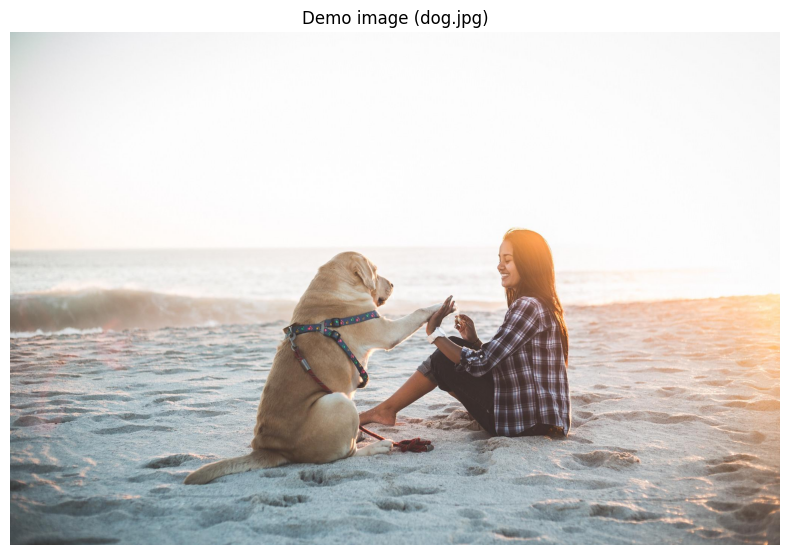

In [11]:
from PIL import Image  # 导入 Pillow 图像处理库；Image 类提供 open/convert/resize 等图像 IO 接口
import torch  # 导入 PyTorch 深度学习框架；提供 Tensor 计算、自动微分、设备管理等核心能力
from transformers import (  # 从 HuggingFace transformers 库按需导入 BLIP 各任务专用模型类
    BlipProcessor,                    # 统一预处理器：内部封装图像处理器（resize→归一化→转Tensor）和文本分词器（BERT WordPiece），输出字典含 pixel_values / input_ids / attention_mask
    BlipForConditionalGeneration,     # 图像描述生成模型（Image Captioning）：ViT 视觉编码器 + BERT-like 因果语言模型解码器，支持 Beam Search / Nucleus Sampling 等多种解码策略
    BlipForQuestionAnswering,         # 视觉问答模型（VQA）：在 BlipForConditionalGeneration 基础上经 VQA v2 数据集微调，以生成式而非分类式范式输出答案
    BlipForImageTextRetrieval         # 图像-文本检索/匹配模型：ViT 编码器 + BERT 文本编码器 + ITC 投影头 + ITM 二分类头，支持 use_itm_head 参数切换两种评分模式
)
import requests  # 导入 HTTP 请求库；用于在本地图像不存在时从网络 URL 下载演示图像的字节流
from io import BytesIO  # 导入字节流包装类；将 HTTP 响应的二进制内容（bytes）包装成类文件对象，供 PIL.Image.open() 直接读取
import warnings  # 导入标准库警告管理模块；filterwarnings 可按消息模式过滤指定警告，避免冗余信息干扰输出
import matplotlib.pyplot as plt  # 导入 matplotlib 绘图库；pyplot 提供类似 MATLAB 的图像绘制接口，可在 Notebook 中内联显示图像

# 过滤 transformers 加载预训练权重时打印的非关键性警告，保持控制台输出简洁
# message 参数使用正则前缀匹配，只要警告消息以该字符串开头即被屏蔽
warnings.filterwarnings("ignore", message="Some weights of BlipModel were not initialized")  # 屏蔽：新增 pooler 层权重随机初始化提示（属于正常现象，不影响推理）
warnings.filterwarnings("ignore", message="`BlipModel` is going to be deprecated")          # 屏蔽：BlipModel 基类弃用警告（实际使用其任务子类，不受影响）

# 自动检测当前运行环境是否有可用 GPU；优先使用 CUDA 加速推理，否则退回 CPU
# torch.device 返回 torch.device 对象（str 类型标识，如 "cuda" 或 "cpu"），后续 .to(device) 统一使用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  # 打印当前推理设备名称，便于确认运行环境是否符合预期


def load_demo_image():
    """
    加载演示用图像，供四项任务共享使用。

    策略：优先读取本地 demo.jpg（减少网络依赖）；
    若本地文件不存在（FileNotFoundError），则从 Salesforce 官方 CDN 下载。

    Returns:
        PIL.Image.Image: 已统一转为 RGB 三通道格式的演示图像对象。
            - 模式为 'RGB'，通道顺序为 R/G/B，无 Alpha 透明通道
            - 尺寸（image.size）为 (宽, 高)，单位像素，例如 (640, 480)
            - 该对象可直接传入 BlipProcessor 进行图像预处理
    """
    try:
        # Image.open() 以懒加载方式打开图像文件，返回 PIL.Image.Image 对象
        # .convert('RGB') 将任意模式（L/RGBA/P 等）统一转为 RGB 三通道，确保与 ViT 输入格式一致
        image = Image.open('dog.jpg').convert('RGB')
        print("Loaded local image: dog.jpg")  # 提示：成功从本地路径读取图像
    except FileNotFoundError:
        # 本地文件不存在时，通过 requests 从官方 CDN 下载演示图（一张沙滩上带狗的女性图片）
        img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'  # 演示图像的网络地址（str 类型），来自 Salesforce Research 官方 CDN
        response = requests.get(img_url)  # 发送 HTTP GET 请求；response.content 为图像的原始字节数据（bytes 类型）
        # BytesIO 将 bytes 数据包装为内存中的类文件对象；Image.open() 可直接从中解析图像格式
        image = Image.open(BytesIO(response.content)).convert('RGB')  # 解析字节流为 PIL.Image 并统一转为 RGB
        print("Loaded image from URL")  # 提示：图像来自网络下载
        image.save('dog.jpg')          # 将下载的图像保存到本地 demo.jpg，下次运行时直接从本地读取，无需重复下载
        print("Saved image to dag.jpg")  # 提示：图像已保存到当前工作目录下的 demo.jpg 文件

    # image.size 返回元组 (width, height)，单位为像素；注意 PIL 的宽高顺序与 NumPy (H, W) 相反
    print(f"Image size: {image.size}")  # 打印原始图像分辨率，例如 "(640, 480)" 表示宽 640 像素、高 480 像素
    return image  # 返回 PIL.Image.Image 对象，供后续各演示函数传入 BlipProcessor 进行预处理


# =============================================================================
# 2.1.1 图像描述生成（Image Captioning）
# =============================================================================
def image_captioning_demo():
    """
    演示任务 2.1.1：给定一张图像，使用 BLIP 自动生成自然语言描述（Image Caption）。

    使用模型：BlipForConditionalGeneration（Salesforce/blip-image-captioning-base）
        - 视觉编码器：ViT-Base/16，将 384×384 图像切分为 576 个 patch，加 [CLS] 共 577 个 token
        - 文本解码器：12 层 BERT-like 因果语言模型，每步以图像特征为条件自回归生成下一个 token

    分别对比两种解码策略的生成质量与多样性：
        - Beam Search（集束搜索）：确定性解码，输出质量高、可复现，适合评测
        - Nucleus Sampling（核采样）：随机性解码，输出多样，适合需要创意变体的场景
    """
    print("\n" + "="*50)  # 打印分隔线，在控制台中清晰区分不同任务的输出区域
    print("2.1.1 IMAGE CAPTIONING")  # 打印当前任务编号与名称
    print("="*50)  # 打印分隔线

    image = load_demo_image()  # 调用辅助函数加载演示图像，返回 PIL.Image.Image 对象

    # BlipProcessor.from_pretrained() 从 HuggingFace Hub 或本地 cache 加载预训练处理器
    # 返回 BlipProcessor 对象，内部包含：
    #   - image_processor（BlipImageProcessor）：负责 resize → 归一化 → 转 Tensor
    #   - tokenizer（BertTokenizerFast）：负责文本 WordPiece 分词 → token ID 序列
    processor = BlipProcessor.from_pretrained(
        "Salesforce/blip-image-captioning-base",  # 模型 Hub ID（str），与下方 model 配套使用
        cache_dir="./model_cache/BLIP",           # 本地缓存目录（str），避免重复下载
        use_fast=True,                            # 显式指定使用快速图像处理器（Rust 实现），消除 slow processor 警告；v4.50 后将成为默认行为
    )

    # BlipForConditionalGeneration.from_pretrained() 加载完整的图像描述生成模型
    # 返回 BlipForConditionalGeneration 对象，包含：
    #   - vision_model（BlipVisionModel / ViT）：图像编码器，输出形状 (B, num_patches+1, 768)
    #   - text_decoder（BlipTextLMHeadModel）：自回归解码器，输出形状 (B, dec_len, vocab_size)
    model = BlipForConditionalGeneration.from_pretrained(
        "Salesforce/blip-image-captioning-base",  # 与 processor 对应的同名 checkpoint（str）
        cache_dir="./model_cache/BLIP",           # 本地缓存目录（str），与 processor 共用
    )
    # .to(device) 将模型所有参数和缓冲区从 CPU 迁移到指定设备（cuda/cpu）
    # 迁移后推理时输入张量也须在同一设备，否则会报 RuntimeError
    model = model.to(device)

    # sum(p.numel() ...) 遍历所有 requires_grad=True 的参数张量，.numel() 返回该张量的元素总数（int）
    # 除以 1e6 转换为百万（M）单位，便于与论文参数量对比（blip-image-captioning-base ≈ 247M）
    print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M")

    # processor() 同时对图像进行预处理，返回 BatchFeature 字典，包含：
    #   - pixel_values（Tensor）：归一化后的图像张量，形状 (1, 3, H, W)
    #       · dim0=1：单张图像构成的批次
    #       · dim1=3：RGB 三通道
    #       · dim2/dim3=H/W：处理器目标分辨率（blip-image-captioning-base 默认 384×384）
    # .to(device) 将输入张量迁移到与模型相同的设备
    inputs = processor(image, return_tensors="pt").to(device)

    # torch.no_grad() 上下文管理器：关闭自动微分引擎，推理阶段无需存储中间梯度，节省约 50% 显存
    with torch.no_grad():

        # ========================== 解码策略一：Beam Search（集束搜索）==========================
        # 原理：每步保留概率最高的 num_beams 条候选序列，最终选择整体对数概率最大的序列
        # 优点：输出质量稳定，可完全复现；缺点：计算量是贪心搜索的 num_beams 倍，多样性差
        print("\nBeam Search Caption:")  # 打印解码策略标识，便于区分两种方式的输出

        # model.generate() 自回归生成 token 序列，返回 Tensor，形状 (batch_size, gen_len)
        #   · dim0=batch_size：批次中序列数量（此处为 1）
        #   · dim1=gen_len：实际生成的 token 数量（≤ max_length，遇 EOS 提前停止）
        out = model.generate(
            **inputs,        # 解包输入字典，传入 pixel_values 等图像特征
            max_length=50,   # 生成序列的最大 token 数量（int），含特殊 token；超出后强制截断
            num_beams=3,     # Beam 数量（int）：同时维持 3 条候选路径，值越大质量越高但速度越慢
            early_stopping=True  # 当所有 beam 均生成 EOS token 时提前终止，避免无效计算（bool）
        )

        # processor.decode() 将 token ID 序列（1D Tensor）反查词表，还原为可读字符串
        # skip_special_tokens=True：跳过 [CLS]、[SEP]、[PAD] 等特殊符号，输出纯净文本（str）
        caption_beam = processor.decode(out[0], skip_special_tokens=True)  # out[0]：取批次第一条序列，形状 (gen_len,)
        print(f"Caption: {caption_beam}")  # 打印 Beam Search 生成的图像描述文本

        # ========================== 解码策略二：Nucleus Sampling（核采样）==========================
        # 原理：每步从概率累积超过 top_p 的最小词集合（"核"）中随机采样下一个 token
        # 优点：兼顾质量与多样性，每次运行结果不同；缺点：受随机种子影响，不可完全复现
        print("\nNucleus Sampling Caption:")  # 打印解码策略标识

        out = model.generate(
            **inputs,        # 解包图像输入
            max_length=50,   # 最大生成 token 数量（int），与 Beam Search 保持一致便于对比
            do_sample=True,  # 启用随机采样模式（bool=True）；与 num_beams>1 的 Beam Search 互斥
            top_p=0.9,       # 核采样概率阈值（float，范围 0~1）：仅从累积概率达到 90% 的候选词中采样，排除长尾低概率词
            temperature=0.7  # 温度系数（float）：对 logits 除以 temperature 后再做 softmax；
                             # <1.0 时分布更尖锐（倾向高概率词，更保守）；>1.0 时更平滑（更随机多样）
        )
        # 同 Beam Search，解码 token ID → 文本字符串，跳过特殊符号
        caption_sample = processor.decode(out[0], skip_special_tokens=True)  # out[0] 形状 (gen_len,)，取第一条序列
        print(f"Caption: {caption_sample}")  # 打印 Nucleus Sampling 生成的图像描述文本


# =============================================================================
# 2.1.2 视觉问答（Visual Question Answering）
# =============================================================================
def visual_question_answering_demo():
    """
    演示任务 2.1.2：给定图像和自然语言问题，使用 BLIP 生成自然语言答案（生成式 VQA）。

    使用模型：BlipForQuestionAnswering（Salesforce/blip-vqa-base）
        - 与 BlipForConditionalGeneration 共享架构（ViT 编码器 + BERT-like 解码器）
        - 在 VQA v2 数据集（约 120 万图文问答对）上微调，专注于问答推理能力
        - 采用生成式（seq2seq）范式而非分类式：答案为自由形式文本，不限于固定候选集

    覆盖 5 种问题类型：位置、动作、物体识别、场景/天气、颜色属性，全面验证模型的视觉理解能力。
    """
    print("\n" + "="*50)  # 打印分隔线，区分控制台中不同任务的输出区域
    print("2.1.2 VISUAL QUESTION ANSWERING")  # 打印任务编号与名称
    print("="*50)  # 打印分隔线

    image = load_demo_image()  # 加载演示图像，返回 PIL.Image.Image 对象（RGB 三通道）

    # BlipProcessor.from_pretrained() 加载与 blip-vqa-base 配套的预处理器
    # 内部分词器已按 VQA 微调 checkpoint 的词表配置，确保 input_ids 与模型嵌入层对齐
    processor = BlipProcessor.from_pretrained(
        "Salesforce/blip-vqa-base",    # VQA 微调 checkpoint 的 Hub ID（str）
        cache_dir="./model_cache/BLIP",  # 本地缓存目录（str），避免重复下载
        use_fast=True,                   # 显式指定使用快速图像处理器（Rust 实现），消除 slow processor 警告；v4.50 后将成为默认行为
    )

    # BlipForQuestionAnswering.from_pretrained() 加载 VQA 微调模型
    # 返回 BlipForQuestionAnswering 对象，结构与 BlipForConditionalGeneration 相同，
    # 区别在于 forward 时将问题文本作为解码器前缀（decoder_input_ids）传入，引导答案生成
    model = BlipForQuestionAnswering.from_pretrained(
        "Salesforce/blip-vqa-base",    # 与 processor 对应的同名 VQA checkpoint（str）
        cache_dir="./model_cache/BLIP",  # 本地缓存目录（str）
    )
    model = model.to(device)  # 将模型所有参数迁移到目标设备（cuda/cpu），与后续输入张量设备保持一致

    # 统计模型全部可训练参数的总元素数量，转换为百万（M）单位
    # p.numel()：返回参数张量的标量元素总数（int）；requires_grad=True 表示该参数参与梯度更新
    print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M")

    # 定义 5 道覆盖不同推理维度的测试问题（list of str），验证模型的多类型视觉理解能力
    questions = [
        "where is the woman sitting?",   # 位置类：考查模型对图中主体空间位置的感知（预期答案如 "beach"）
        "what is the woman doing?",      # 动作类：考查模型对主体行为的理解（预期答案如 "sitting"）
        "what animal is in the image?",  # 物体识别类：考查模型识别图中非人类主体（预期答案如 "dog"）
        "what is the weather like?",     # 场景/天气类：考查模型对图像整体氛围的判断（预期答案如 "sunny"）
        "what color is the dog?"         # 颜色属性类：考查模型对特定物体细粒度属性的识别（预期答案如 "brown"）
    ]

    for question in questions:  # 遍历问题列表，对每道题单独推理并打印结果
        # processor() 同时接收图像（PIL.Image）和问题文本（str），执行：
        #   · 图像 → pixel_values（Tensor），形状 (1, 3, H, W)
        #       - dim0=1：单张图像批次
        #       - dim1=3：RGB 三通道
        #       - dim2/dim3：处理器目标分辨率（blip-vqa-base 默认 480×480）
        #   · 问题文本 → input_ids（Tensor），形状 (1, seq_len)；attention_mask（Tensor），形状 (1, seq_len)
        #       - dim0=1：单条问题批次
        #       - dim1=seq_len：分词后含 [CLS]/[SEP]/padding 的 token 总数
        inputs = processor(image, question, return_tensors="pt").to(device)  # BatchFeature 字典，各张量已迁移至目标设备

        with torch.no_grad():  # 推理阶段关闭梯度计算，节省显存，加快速度
            # model.generate() 以图像特征为视觉条件、问题文本为前缀，自回归生成答案 token 序列
            # 返回 Tensor，形状 (1, gen_len)：dim0=批次大小=1，dim1=生成的 token 数量（≤ max_length）
            out = model.generate(**inputs, max_length=50)  # max_length=50（int）：答案最多 50 个 token，防止无限生成

            # processor.decode() 将 token ID 序列（1D Tensor）反查词表还原为字符串（str）
            # skip_special_tokens=True：过滤 [CLS]/[SEP]/[PAD] 等特殊符号，输出纯净答案文本
            answer = processor.decode(out[0], skip_special_tokens=True)  # out[0] 形状 (gen_len,)，取批次第一条（也是唯一一条）

            print(f"Q: {question}")  # 打印当前问题原文（英文）
            print(f"A: {answer}\n")  # 打印模型生成的答案文本，末尾换行以区分各题目输出


# =============================================================================
# 辅助函数：适配 transformers>=4.53 的 BlipForImageTextRetrieval API
# 说明：新版本 forward() 不再直接在 outputs 中暴露 image_embeds / text_embeds 属性，
#       需手动调用各子模块分别提取，再经投影头映射并 L2 归一化，才能用于相似度计算。
# =============================================================================
def extract_itm_image_features(model, pixel_values):
    """
    从 BlipForImageTextRetrieval 手动提取并归一化图像特征向量。

    流程：pixel_values → ViT vision_model → 取 [CLS] 隐藏状态 → vision_proj 投影 → L2 归一化

    Args:
        model (BlipForImageTextRetrieval): 已加载并迁移至目标设备的 BLIP 图文检索模型实例。
            内部关键子模块：
                - model.vision_model（BlipVisionModel）：ViT 图像编码器
                - model.vision_proj（nn.Linear）：图像 ITC 投影头，将 hidden_size → embed_dim
        pixel_values (Tensor): 经过 BlipProcessor 预处理的图像张量。
            形状 (batch_size, 3, H, W)：
                · dim0 batch_size：批次中的图像数量
                · dim1=3：RGB 三通道像素值（经归一化，范围约 [-1, 1]）
                · dim2=H / dim3=W：ViT 输入分辨率（blip-itm-base-coco 默认 384×384）

    Returns:
        Tensor: L2 归一化后的图像特征向量。
            形状 (batch_size, embed_dim)：
                · dim0 batch_size：与输入图像数量一致
                · dim1 embed_dim：ITC 投影空间维度（blip-itm-base-coco 为 256）
            特性：每行向量的 L2 范数为 1.0，向量间的点积等价于余弦相似度，可直接用于排序或检索。
    """
    # model.vision_model() 对图像张量执行 ViT 前向传播，返回 BaseModelOutputWithPooling 对象
    # 其 [0]（即 last_hidden_state）为最后一层 Transformer 的所有位置输出
    vision_outputs = model.vision_model(pixel_values=pixel_values)

    # vision_outputs[0] 即 last_hidden_state，形状 (batch_size, num_patches+1, hidden_size)
    #   · dim0 batch_size：批次中图像数量
    #   · dim1 num_patches+1：196 个 16×16 图像 patch（14×14 grid）+ 1 个 [CLS] 全局 token = 197
    #   · dim2 hidden_size：ViT-Base/16 隐藏层维度，值为 768
    image_hidden = vision_outputs[0]

    # image_hidden[:, 0, :]：切片取所有批次中索引为 0 的位置（即 [CLS] token）的特征
    # 形状 (batch_size, hidden_size) = (batch_size, 768)
    # [CLS] token 通过 ViT 的全局自注意力机制聚合了整张图像的语义信息，代表图像全局嵌入
    # model.vision_proj()：nn.Linear(768 → 256)，将 ViT 特征投影到 ITC 对比学习嵌入空间
    # F.normalize(..., dim=-1)：沿最后一维（embed_dim 轴）做 L2 归一化，使每个向量范数为 1.0
    # 输出形状 (batch_size, embed_dim) = (batch_size, 256)
    return torch.nn.functional.normalize(model.vision_proj(image_hidden[:, 0, :]), dim=-1)


def extract_itm_text_features(model, input_ids, attention_mask, pixel_values=None):
    """
    从 BlipForImageTextRetrieval 手动提取并归一化文本特征向量。
    可选择是否注入图像上下文：提供 pixel_values 时文本编码器通过交叉注意力感知图像内容。

    流程（无图像）：input_ids → BERT text_encoder（纯文本编码）→ 取 [CLS] 隐藏状态 → text_proj 投影 → L2 归一化
    流程（有图像）：pixel_values → ViT → 图像特征 → 作为 encoder_hidden_states 传入 text_encoder
                   （文本编码器通过交叉注意力层融合图像信息）→ 取 [CLS] 隐藏状态 → text_proj 投影 → L2 归一化

    Args:
        model (BlipForImageTextRetrieval): 已加载并迁移至目标设备的 BLIP 图文检索模型实例。
            内部关键子模块：
                - model.vision_model（BlipVisionModel）：仅在提供 pixel_values 时使用
                - model.text_encoder（BlipTextModel）：BERT-base 双向文本编码器（含交叉注意力层）
                - model.text_proj（nn.Linear）：文本 ITC 投影头，将 hidden_size → embed_dim
        input_ids (Tensor): 文本 token ID 序列。
            形状 (batch_size, seq_len)：
                · dim0 batch_size：批次中句子数量
                · dim1 seq_len：分词后含 [CLS]/[SEP]/[PAD] 的 token 总数（BERT 默认最长 512）
        attention_mask (Tensor): 文本自注意力掩码（与 input_ids 形状相同）。
            形状 (batch_size, seq_len)：
                · 有效 token 位置值为 1，[PAD] 填充位置值为 0；防止注意力关注无效 padding
        pixel_values (Tensor, optional): 图像张量，形状 (batch_size, 3, H, W)。
            · 提供时：ViT 编码图像，结果作为 encoder_hidden_states 注入文本编码器的交叉注意力层
            · 为 None 时：文本编码器以纯语言模式运行，无图像上下文

    Returns:
        Tensor: L2 归一化后的文本特征向量。
            形状 (batch_size, embed_dim)：
                · dim0 batch_size：与输入句子数量一致
                · dim1 embed_dim：ITC 投影空间维度（blip-itm-base-coco 为 256）
            特性：每行向量 L2 范数为 1.0，与归一化图像特征做点积即得余弦相似度。
    """
    if pixel_values is not None:  # 提供图像时，启用图文联合编码路径（文本能"看到"图像内容）
        # 通过 ViT 编码图像，获取所有 patch 位置的隐藏状态序列
        vision_outputs = model.vision_model(pixel_values=pixel_values)
        # image_hidden 形状 (batch_size, num_patches+1, hidden_size) = (B, 197, 768)
        #   · dim0 B：批次中图像数量
        #   · dim1 197：196 个图像 patch + 1 个 [CLS] token，提供完整的图像空间信息
        #   · dim2 768：ViT-Base/16 隐藏层特征维度
        image_hidden = vision_outputs[0]

        # torch.ones() 构造全 1 注意力掩码，形状 (B, 197)
        # image_hidden.size()[:-1] 取除最后维（hidden_size）外的所有维度，即 (B, 197)
        # 全部设为 1 表示所有 patch 位置均有效（无 padding），文本编码器可自由关注任意图像区域
        # dtype=torch.long：注意力掩码类型须为整型（0/1），float 会报错
        image_atts = torch.ones(image_hidden.size()[:-1], dtype=torch.long, device=image_hidden.device)

        # model.text_encoder() 执行 BERT 前向传播，返回 BaseModelOutput 对象
        # encoder_hidden_states：将图像特征注入 BERT 各层的交叉注意力（Cross-Attention）
        #   的 Key/Value，使文本 token 能通过注意力权重"关注"图像 patch 的视觉信息
        # encoder_attention_mask：对应图像特征的注意力掩码，全 1 表示所有图像位置均可被关注
        text_outputs = model.text_encoder(
            input_ids=input_ids,                   # 文本 token ID 序列，形状 (B, seq_len)
            attention_mask=attention_mask,          # 文本自注意力掩码，1=有效，0=padding，形状 (B, seq_len)
            encoder_hidden_states=image_hidden,     # 图像特征序列作为交叉注意力的 Key/Value，形状 (B, 197, 768)
            encoder_attention_mask=image_atts,      # 图像注意力掩码，全 1，形状 (B, 197)
        )
    else:  # 不提供图像时，仅执行纯文本编码（无交叉注意力，不感知图像内容）
        text_outputs = model.text_encoder(
            input_ids=input_ids,           # 文本 token ID 序列，形状 (B, seq_len)
            attention_mask=attention_mask, # 文本自注意力掩码，形状 (B, seq_len)
        )

    # text_outputs.last_hidden_state：BERT 最后一层所有 token 的隐藏状态，形状 (B, seq_len, hidden_size)
    # [:, 0, :]：切片取索引 0 位置（即 [CLS] token）的特征，形状 (B, hidden_size) = (B, 768)
    # [CLS] token 经 BERT 全层双向注意力聚合了完整句子语义，代表全局文本嵌入
    # model.text_proj()：nn.Linear(768 → 256)，投影到 ITC 对比学习嵌入空间
    # F.normalize(..., dim=-1)：沿 embed_dim 轴做 L2 归一化，输出形状 (B, 256)，范数为 1.0
    return torch.nn.functional.normalize(
        model.text_proj(text_outputs.last_hidden_state[:, 0, :]), dim=-1
    )


# =============================================================================
# 2.1.3 特征提取（Feature Extraction）
# =============================================================================
def feature_extraction_demo():
    """
    演示任务 2.1.3：使用 BLIP 提取图像和文本的 L2 归一化特征向量，
    并通过余弦相似度和 ITM 二分类概率两种方式量化图文语义对齐程度。

    使用模型：BlipForImageTextRetrieval（Salesforce/blip-itm-base-coco）
        - 在 COCO 数据集上进行图文对比（ITC）和图文匹配（ITM）联合训练/微调
        - 包含 ITC 投影头（vision_proj / text_proj）和 ITM 二分类头（itm_head）
        - use_itm_head=True：通过 itm_head 输出匹配 logits，适合精细匹配判断
        - use_itm_head=False：直接返回 ITC 归一化相似度得分，适合大规模检索粗排

    本演示展示三种特征使用方式：
        1. 端到端 forward（use_itm_head=True）：获取 ITM 匹配 logits 和概率
        2. 端到端 forward（use_itm_head=False）：获取 ITC 余弦相似度
        3. 手动分步提取：分别调用 vision_model 和 text_encoder 获取独立特征向量
    """
    print("\n" + "="*50)  # 打印分隔线，区分控制台中不同任务的输出
    print("2.1.3 FEATURE EXTRACTION")  # 打印任务编号与名称
    print("="*50)  # 打印分隔线

    image = load_demo_image()  # 加载演示图像，返回 PIL.Image.Image 对象（RGB 三通道）

    from transformers import BlipForImageTextRetrieval  # 局部导入 BLIP 图文检索模型类（已在文件头导入，此处再次显式导入以提示模型类型）

    # BlipProcessor.from_pretrained() 加载与 blip-itm-base-coco 配套的预处理器
    # 内部图像处理器目标分辨率为 384×384（与 blip-image-captioning-base 相同）
    processor = BlipProcessor.from_pretrained(
        "Salesforce/blip-itm-base-coco", # COCO 图文检索微调 checkpoint 的 Hub ID（str）
        cache_dir="./model_cache/BLIP",  # 本地缓存目录（str）
        use_fast=True,                   # 显式指定使用快速图像处理器（Rust 实现），消除 slow processor 警告；v4.50 后将成为默认行为
    )

    # BlipForImageTextRetrieval.from_pretrained() 加载完整的图文检索模型
    # 返回 BlipForImageTextRetrieval 对象，包含：
    #   - vision_model（BlipVisionModel）：ViT-Base/16 图像编码器
    #   - text_encoder（BlipTextModel）：BERT-base 文本编码器（含交叉注意力）
    #   - vision_proj（Linear 768→256）：图像 ITC 投影头
    #   - text_proj（Linear 768→256）：文本 ITC 投影头
    #   - itm_head（Linear 768→2）：ITM 二分类头，输出 [不匹配 logit, 匹配 logit]
    model = BlipForImageTextRetrieval.from_pretrained(
        "Salesforce/blip-itm-base-coco", # 与 processor 对应的同名 checkpoint（str）
        cache_dir="./model_cache/BLIP",  # 本地缓存目录（str）
    )
    model = model.to(device)  # 将模型所有参数和缓冲区迁移到目标设备

    # 统计并打印模型全部可训练参数量（百万为单位）
    print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M")

    text = "a woman sitting on the beach with a dog"  # 候选描述文本（str），与图像内容高度匹配，用于验证模型的正样本识别能力

    # processor() 同时对图像和文本进行预处理，返回 BatchFeature 字典，包含：
    #   - pixel_values（Tensor）：形状 (1, 3, 384, 384)，dim0=批次=1，dim1=RGB，dim2/dim3=分辨率
    #   - input_ids（Tensor）：形状 (1, seq_len)，文本 token ID 序列，dim0=批次=1，dim1=token 数
    #   - attention_mask（Tensor）：形状 (1, seq_len)，1=有效 token，0=padding
    # padding=True：对批次内最长序列进行 padding 对齐（单条输入时无实际影响）
    inputs = processor(images=image, text=text, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():  # 推理阶段关闭梯度，节省显存并加快计算

        # ======================= 方式一：ITM 二分类 logits（use_itm_head=True）=======================
        # model forward 时：
        #   1. ViT 编码图像 → 图像特征序列 (B, 197, 768)
        #   2. BERT 以图像特征为 Key/Value 编码文本 → [CLS] 特征 (B, 768)
        #   3. itm_head（Linear 768→2）将 [CLS] 特征映射为 2 维 logits
        # outputs.itm_score：ITM 输出 logits，形状 (batch_size, 2)
        #   · dim0=batch_size：批次中图像-文本对的数量（此处为 1）
        #   · dim1=2：第 0 维=不匹配 logit，第 1 维=匹配 logit（未经 softmax 的原始分数）
        outputs = model(**inputs, use_itm_head=True)
        print(f"ITM logits shape: {outputs.itm_score.shape}")  # 打印 logits 形状，应为 torch.Size([1, 2])

        # F.softmax(..., dim=1)：沿 dim1（类别轴）做 softmax，将 logits 转为概率分布，两类概率之和为 1.0
        # [0, 1]：取批次第 0 条、类别索引 1（"匹配"类）的概率值（float）
        # .item()：将标量 Tensor 转为 Python float，便于格式化打印
        itm_prob = torch.nn.functional.softmax(outputs.itm_score, dim=1)[0, 1].item()
        print(f"ITM match probability: {itm_prob:.4f}")  # 打印匹配概率，值越接近 1.0 表示图文越匹配

        # ======================= 方式二：ITC 归一化相似度（use_itm_head=False）=======================
        # use_itm_head=False 时 model forward：
        #   1. ViT 编码图像 → [CLS] 特征 → vision_proj → L2 归一化 → 图像嵌入向量
        #   2. BERT 编码文本 → [CLS] 特征 → text_proj → L2 归一化 → 文本嵌入向量
        #   3. 计算两者点积（等价于余弦相似度），输出标量相似度得分
        # retrieval_outputs.itm_score：ITC 余弦相似度得分，形状 (batch_size,) 或标量
        retrieval_outputs = model(**inputs, use_itm_head=False)
        # .squeeze()：去除批次维度，得到标量 Tensor；.item()：转为 Python float
        print(f"Retrieval similarity: {retrieval_outputs.itm_score.squeeze().item():.4f}")  # 打印 ITC 相似度，范围约 [-1, 1]

        # ======================= 方式三：手动分步提取独立特征向量 =======================
        print("\n--- Separate Feature Extraction ---")  # 提示开始独立特征提取演示区域

        # 单独对图像进行预处理（不传入文本），processor 只生成 pixel_values
        # 返回 BatchFeature，形状 pixel_values: (1, 3, 384, 384)
        image_inputs = processor(images=image, return_tensors="pt").to(device)

        # 调用辅助函数提取纯图像特征（内部：ViT → [CLS] → vision_proj → L2 归一化）
        # 返回形状 (1, 256)：dim0=批次=1，dim1=embed_dim=256（ITC 投影空间维度）
        image_features = extract_itm_image_features(model, image_inputs["pixel_values"])
        print(f"Pure image features shape: {image_features.shape}")  # 打印图像特征形状，应为 torch.Size([1, 256])

        # 单独对文本进行预处理（不传入图像），processor 生成 input_ids 和 attention_mask
        # 返回 BatchFeature，形状 input_ids: (1, seq_len)，attention_mask: (1, seq_len)
        text_inputs = processor(text=text, return_tensors="pt", padding=True).to(device)

        # 调用辅助函数提取融合图像上下文的文本特征
        # （内部：ViT 编码图像 → 图像特征作为 encoder_hidden_states → BERT 交叉注意力融合 → [CLS] → text_proj → L2 归一化）
        # pixel_values 参数启用图文交叉注意力，使文本特征中包含图像的视觉信息
        # 返回形状 (1, 256)：dim0=批次=1，dim1=embed_dim=256
        text_features = extract_itm_text_features(
            model,
            text_inputs["input_ids"],                      # 文本 token ID 序列，形状 (1, seq_len)
            text_inputs["attention_mask"],                 # 文本注意力掩码，形状 (1, seq_len)
            pixel_values=image_inputs["pixel_values"],     # 传入图像张量以启用交叉注意力，形状 (1, 3, 384, 384)
        )
        print(f"Text features (with image context) shape: {text_features.shape}")  # 应为 torch.Size([1, 256])

        # torch.matmul(A, B.T)：矩阵乘法计算余弦相似度
        # image_features 形状 (1, 256)，text_features.T 形状 (256, 1) → 结果形状 (1, 1)
        # .squeeze()：压缩为标量 Tensor；两向量已 L2 归一化，点积值 ∈ [-1, 1]，等价于余弦相似度
        similarity_score = torch.matmul(image_features, text_features.T).squeeze()
        print(f"Normalized similarity score: {similarity_score.item():.4f}")  # 打印归一化相似度，接近 1.0 表示高度语义对齐

        # image_features.shape[1]：取特征向量的第 1 维大小，即 embed_dim（ITC 嵌入空间维度，值为 256）
        print(f"Feature dimension: {image_features.shape[1]}")  # 打印嵌入向量维度数，应为 256

        # .norm(dim=1)：沿 dim1（特征维度）计算每条向量的 L2 范数（欧氏长度）；L2 归一化后范数应为 1.0
        # .item()：将 1 元素 Tensor 转为 Python float
        print(f"Image feature norm: {image_features.norm(dim=1).item():.4f}")  # 验证图像特征已归一化，应约为 1.0000
        print(f"Text feature norm: {text_features.norm(dim=1).item():.4f}")    # 验证文本特征已归一化，应约为 1.0000


# =============================================================================
# 2.1.4 图像-文本匹配（Image-Text Matching）
# =============================================================================
def image_text_matching_demo():
    """
    演示任务 2.1.4：给定同一张图像和多段候选文本，逐一计算图文匹配分数，
    验证 BLIP 对"图文语义一致性"的细粒度判断能力。

    使用模型：BlipForImageTextRetrieval（Salesforce/blip-itm-base-coco）
        - 同时使用 ITM 二分类概率和 ITC 余弦相似度两种评分方式
        - ITM 概率（use_itm_head=True）：经交叉注意力图文融合后做二分类，对语义细节更敏感
        - ITC 余弦相似度（use_itm_head=False）：独立嵌入空间的向量相似度，计算效率更高
    通过对比 5 段不同匹配程度的文本（高度匹配 / 部分匹配 / 完全不匹配），
    直观观察两种评分方式对图文语义对齐程度的区分能力。
    """
    print("\n" + "="*50)  # 打印分隔线，区分控制台输出区域
    print("2.1.4 IMAGE-TEXT MATCHING")  # 打印任务编号与名称
    print("="*50)  # 打印分隔线

    image = load_demo_image()  # 加载演示图像，返回 PIL.Image.Image 对象（RGB 三通道）

    from transformers import BlipForImageTextRetrieval  # 局部导入，明确当前任务使用的模型类型

    # 加载与 blip-itm-base-coco 配套的预处理器（图像 resize 384×384，BERT WordPiece 分词）
    processor = BlipProcessor.from_pretrained(
        "Salesforce/blip-itm-base-coco", # COCO 微调 checkpoint Hub ID（str）
        cache_dir="./model_cache/BLIP",  # 本地缓存目录（str）
        use_fast=True,                   # 显式指定使用快速图像处理器（Rust 实现），消除 slow processor 警告；v4.50 后将成为默认行为
    )

    # 加载 BLIP 图文检索模型（ITM + ITC 双评分头）
    model = BlipForImageTextRetrieval.from_pretrained(
        "Salesforce/blip-itm-base-coco", # 与 processor 对应的同名 checkpoint（str）
        cache_dir="./model_cache/BLIP",  # 本地缓存目录（str）
    )
    model = model.to(device)  # 将模型迁移至目标设备，确保与输入张量在同一设备

    # 定义 5 段覆盖不同匹配程度的候选文本（list of str），用于全面测试模型的区分能力
    texts = [
        "a woman sitting on the beach with a dog",  # 高度匹配：精准描述图像主体（女性）、动作（坐着）、场景（沙滩）和伴随物（狗），预期 ITM 概率最高
        "a man playing football in the park",       # 完全不匹配：主体（男性 vs. 女性）、动作（踢球 vs. 坐着）、场景（公园 vs. 沙滩）均不符，预期 ITM 概率最低
        "a person relaxing by the water",           # 部分匹配：场景（水边≈沙滩）和状态（放松≈坐着）正确，但主体性别和伴随物（狗）信息缺失，预期中等分数
        "a dog running on the beach",               # 部分匹配：场景（沙滩）和动物（狗）正确，但主体（狗 vs. 女性）和动作（跑 vs. 坐）有偏差，预期中低分数
        "a beautiful sunset over the ocean"         # 不匹配：描述日落场景，图像中无日落；场景虽涉及海洋，但主体和事件完全不符，预期较低分数
    ]

    print(f"Computing similarity scores for different texts:")  # 打印提示，告知开始批量评分
    print("-" * 60)  # 打印分隔线，区分提示信息与评分结果

    for text in texts:  # 遍历 5 段候选文本，对每段文本分别计算两种匹配分数
        # processor() 同时预处理图像和当前文本，返回 BatchFeature 字典
        #   - pixel_values（Tensor）：形状 (1, 3, 384, 384)，dim0=批次=1，dim1=RGB，dim2/dim3=分辨率
        #   - input_ids（Tensor）：形状 (1, seq_len)，dim0=批次=1，dim1=当前文本分词后 token 数
        #   - attention_mask（Tensor）：形状 (1, seq_len)，1=有效 token，0=padding
        inputs = processor(images=image, text=text, return_tensors="pt", padding=True).to(device)

        with torch.no_grad():  # 推理阶段无需梯度，关闭自动微分引擎节省资源

            # ---- 评分方式一：ITM 二分类概率（精细匹配，需图文交叉注意力融合）----
            # use_itm_head=True：内部执行图文交叉注意力融合后，由 itm_head（Linear 768→2）输出 logits
            # outputs.itm_score 形状 (1, 2)：dim0=批次=1，dim1=2（不匹配 logit / 匹配 logit）
            outputs = model(**inputs, use_itm_head=True)

            # F.softmax(..., dim=1)：对 2 维 logits 做 softmax，得到归一化概率分布
            # itm_score 形状 (1, 2)：[0]取第一条，[1]取"匹配"类概率（float，范围 0~1）
            itm_score = torch.nn.functional.softmax(outputs.itm_score, dim=1)
            match_probability = itm_score[0, 1].item()  # "匹配"类概率（Python float），越接近 1.0 表示越匹配

            # ---- 评分方式二：ITC 余弦相似度（粗排检索，独立嵌入向量点积）----
            # 分步提取图像和文本的 L2 归一化嵌入向量，再计算点积（余弦相似度）
            image_features = extract_itm_image_features(model, inputs["pixel_values"])  # 图像嵌入，形状 (1, 256)
            text_features = extract_itm_text_features(
                model,
                inputs["input_ids"],                   # 文本 token ID，形状 (1, seq_len)
                inputs["attention_mask"],               # 文本注意力掩码，形状 (1, seq_len)
                pixel_values=inputs["pixel_values"],   # 提供图像以启用交叉注意力，形状 (1, 3, 384, 384)
            )                                          # 文本嵌入，形状 (1, 256)

            # torch.matmul(A, B.T)：(1, 256) × (256, 1) → (1, 1)，.squeeze() 压缩为标量 Tensor
            # 两向量已 L2 归一化，点积 ∈ [-1, 1] 等价于余弦相似度；值越接近 1.0 表示语义越相似
            cosine_similarity = torch.matmul(image_features, text_features.T).squeeze().item()  # Python float

            print(f"Text: '{text}'")  # 打印当前候选文本原文
            print(f"ITM Match Probability : {match_probability:.4f}")  # 打印 ITM 二分类"匹配"概率（0~1）
            print(f"Cosine Similarity     : {cosine_similarity:.4f}")  # 打印 ITC 余弦相似度（-1~1）
            print("-" * 60)  # 打印分隔线，区分各条候选文本的评分结果


# =============================================================================
# 综合演示：按序运行全部四个子任务（2.1.1 ~ 2.1.4）
# =============================================================================
def run_all_demos():
    """
    按编号顺序依次调用四个 BLIP 官方接口演示函数，完整运行 2.1.1 ~ 2.1.4 四项任务。

    执行顺序：
        2.1.1 image_captioning_demo()         → 图像描述生成（Beam Search / Nucleus Sampling）
        2.1.2 visual_question_answering_demo() → 视觉问答（5 道不同类型测试题）
        2.1.3 feature_extraction_demo()        → 特征提取（ITM logits / ITC 相似度 / 手动提取）
        2.1.4 image_text_matching_demo()       → 图文匹配（5 段不同匹配程度候选文本评分）

    异常处理：任意子任务发生 Exception 时捕获并打印错误信息，提示检查依赖安装，
              防止单任务报错导致后续演示无法执行。

    Returns:
        None：函数通过 print 直接输出结果到控制台，无显式返回值。
    """
    print("BLIP Model Demonstrations using Transformers Library")  # 打印演示总标题
    print("=" * 60)  # 打印分隔线，标识演示开始

    try:
        image_captioning_demo()            # 运行任务 2.1.1：图像描述生成（Beam Search + Nucleus Sampling）
        visual_question_answering_demo()   # 运行任务 2.1.2：视觉问答（5 题覆盖位置/动作/物体/天气/颜色）
        feature_extraction_demo()          # 运行任务 2.1.3：特征提取（3 种方式：ITM logits / ITC 相似度 / 手动提取）
        image_text_matching_demo()         # 运行任务 2.1.4：图文匹配（5 段候选文本双评分）

        print("\n" + "="*60)  # 打印分隔线，标识所有演示结束
        print("All demonstrations completed successfully!")  # 打印成功完成提示，确认无异常
        print("="*60)  # 打印结束分隔线

    except Exception as e:
        # 捕获所有未预期异常（如模型下载失败、CUDA OOM、依赖缺失等），防止程序崩溃
        print(f"Error occurred: {str(e)}")  # 打印异常类型和错误信息，便于定位问题
        print("Please make sure you have the required dependencies installed:")  # 提示用户检查依赖环境
        print("pip install transformers torch torchvision pillow requests")  # 打印一键安装命令


# =============================================================================
# 程序主入口：直接运行本 .py 文件时执行；作为模块导入时不执行
# =============================================================================
if __name__ == "__main__":
    try:
        import transformers  # 尝试导入 transformers，若未安装则触发 ImportError
        print(f"Transformers version: {transformers.__version__}")  # 打印当前 transformers 版本号（str），便于排查版本兼容问题
        print(f"PyTorch version: {torch.__version__}")              # 打印当前 PyTorch 版本号（str），与 transformers 版本配套使用
        print(f"Device: {device}")                                  # 打印当前推理设备（str，如 "cuda" 或 "cpu"）
        print("-" * 60)  # 打印分隔线，区分环境信息和演示输出
        run_all_demos()  # 启动全部四项演示任务
        # 使用 matplotlib 在 Notebook 输出区域内联显示演示图像
        demo_img = Image.open('dog.jpg').convert('RGB')  # 打开本地 dog.jpg 并转为 RGB 模式，返回 PIL.Image.Image 对象
        plt.figure(figsize=(8, 6))           # 创建画布，figsize=(宽英寸, 高英寸)，控制图像显示尺寸
        plt.imshow(demo_img)                 # 将 PIL.Image 渲染到坐标轴；接受 PIL.Image / np.ndarray (H, W, 3) 格式
        plt.title('Demo image (dog.jpg)')    # 在图像上方添加标题（str）
        plt.axis('off')                      # 关闭坐标轴刻度和边框，使图像显示更简洁
        plt.tight_layout()                   # 自动调整子图间距，防止标题被裁剪
        plt.show()                           # 在 Notebook 输出区域内联渲染并显示图像

    except ImportError as e:
        # 捕获依赖缺失导致的 ImportError，打印缺失包的具体名称
        print(f"Missing dependency: {e}")  # 打印缺失的包名（str），例如 "No module named 'transformers'"
        print("Please install required packages:")  # 提示安装必要依赖
        print("pip install transformers torch torchvision pillow requests")  # 打印 pip 安装命令



In [3]:
%%bash
pip list|grep torchvision 

torchvision               0.27.0+cu132


### 2.2 官方结构展示

#### 2.2.1 两大核心组件

`Salesforce/blip-image-captioning-base` 模型结构说明，两大顶层子模块如下：

- **vision_model**：`BlipVisionModel`（ViT-B/16，patch_size=16，共12层，隐藏维度 768）
  - **输入**：`(batch=1, C=3, H=384, W=384)` RGB 图像张量（blip-base 默认分辨率 384×384）
  - **输出**：`(batch=1, num_tokens=577, d_vit=768)` 视觉特征序列  
    （577 = 576 个 16×16 patch 特征 + 1 个 CLS token；每个 token 为 768 维向量）
  - 训练时**参数可更新**（BLIP 的 ViT 不冻结，与 BLIP-2 不同）

- **text_decoder**：`BlipTextLMHeadModel`（基于 BERT-base 改造的因果语言模型，12层，隐藏维度 768）
  - **输入 1（文本）**：`(batch=1, seq_len, d_bert=768)` 上一步生成的 token 嵌入序列（自回归）
  - **输入 2（图像，交叉注意力层）**：`(batch=1, 577, 768)` 来自 ViT 的视觉特征（作为 K/V）
  - **输出**：`(batch=1, seq_len, vocab_size=30524)` 每个位置上的 token 概率分布，取 argmax 得下一个 token
  - 每层**均含交叉注意力**（与 BLIP-2 Q-Former 的奇偶交替不同，BLIP 每层都做图文融合）

---

#### 2.2.2 文本解码器层内部结构

`text_decoder` 的 12 层每层（`BlipTextLayer`）结构完全相同，包含三个子模块：

1. **`attention`**（自注意力）：文本 token 内部互相关注，实现自回归语言建模  
   - Q/K/V 均来自文本序列自身（768维），因果掩码（causal mask）保证只看到过去 token

2. **`crossattention`**（交叉注意力）：文本 token 关注图像特征，实现图文融合  
   - Q 来自文本序列（768维），K/V 来自 ViT 输出（768维，与文本同维，无需额外投影）

3. **`intermediate → output`**（前馈网络 FFN）：768 → 3072 → 768，扩展比 = 4，GELU 激活

> **BLIP vs BLIP-2 的关键区别**：BLIP 的 text_decoder **每一层**都含交叉注意力，ViT 与文本解码器维度相同（768维），无需额外投影；而 BLIP-2 仅奇偶交替使用交叉注意力，且 ViT 输出需从 1408 维投影到 768 维。

---

#### 2.2.3 数据流向与张量维度变化

```
图像输入  (batch=1, C=3, H=384, W=384)
    │
    │  Conv2d(in=3, out=768, kernel=16×16, stride=16)
    │  384×384 图像切成 (384÷16)²=576 个 patch，每 patch 映射为 768 维
    ▼
Patch 序列  (1, 576, 768)  + CLS token  →  (1, 577, 768)
    │
    │  BlipEncoder：12 层 ViT 自注意力（参数可更新）
    │  每层维持 (1, 577, 768) 不变
    ▼
视觉特征    (1, 577, 768)  ← ViT 编码器最终输出（含 post_layernorm）
    │              ↑
    │    作为 K/V 送入 text_decoder 每层的 crossattention
    ▼
文本嵌入    (1, t, 768)    ← 已生成的 t 个 token 的嵌入向量（自回归逐步扩展）
    │
    │  BlipTextEncoder：12 层，每层先自注意力再交叉注意力再 FFN
    ▼
隐藏状态    (1, t, 768)
    │
    │  BlipTextOnlyMLMHead（cls → predictions → decoder）
    ▼
logits      (1, t, vocab=30524)  →  argmax  →  预测下一个 token id
```

---

#### 2.2.4 关键超参数速查

| 组件 | 参数名 | 数值 | 含义说明 |
|------|--------|------|----------|
| ViT | `patch_size` | 16 | 每个 patch 为 16×16 像素 |
| ViT | `num_patches` | 576 = (384÷16)² | 384×384 图像切分后的 patch 数量 |
| ViT | `hidden_dim` | 768 | ViT-B/16 每个 token 的特征维度 |
| ViT | `num_layers` | 12 | 编码器层数（层索引 0~11） |
| ViT | `ffn_dim` | 3072 = 768×4 | ViT MLP 中间维度，4 倍扩展比 |
| ViT | `qkv合并` | 2304 = 768×3 | Q/K/V 合并投影的输出维度 |
| Text Decoder | `vocab_size` | 30524 | BERT-base 词表大小 |
| Text Decoder | `max_seq_len` | 512 | 最大文本序列长度（位置编码数量） |
| Text Decoder | `hidden_dim` | 768 | 与 ViT 相同，图文融合无需维度转换 |
| Text Decoder | `num_layers` | 12 | 解码器层数，每层均含交叉注意力 |
| Text Decoder | `ffn_dim` | 3072 = 768×4 | FFN 中间维度 |
| MLM Head | `transform` | 768 → 768 | 预测头变换层（含 GELU + LayerNorm） |
| MLM Head | `decoder` | 768 → 30524 | 最终 token 概率预测层 |

```python
# 【模型结构注释说明】
# 以下为 BlipForConditionalGeneration 的完整层级打印输出，附逐行中文注释
# BLIP (Bootstrapping Language-Image Pre-training) 由两大模块组成：
#   ① ViT 视觉编码器（vision_model）：将图像编码为视觉特征序列
#   ② 因果语言模型解码器（text_decoder）：基于 BERT 改造，每层含交叉注意力，自回归生成文本

BlipForConditionalGeneration(                           # 顶级封装类：图像描述生成的完整管线
  # ═══════════════════════════════════════════════════
  # ① 视觉编码器：ViT-B/16，参数可更新（BLIP 不冻结 ViT，与 BLIP-2 不同）
  #    输入: (batch, 3, 384, 384)  输出: (batch, 577, 768)
  # ═══════════════════════════════════════════════════
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      # 将 384×384 图像切割成 (384÷16)²=576 个不重叠的 16×16 patch
      # 每个 patch（3×16×16=768 像素）通过 Conv2d 线性映射为 768 维向量
      # in_channels=3(RGB), out_channels=768(ViT隐藏维), kernel/stride=16(patch尺寸)
      # 输出形状: (batch, 768, H_grid=24, W_grid=24) → reshape → (batch, 576, 768)
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        # 共 12 层 ViT 自注意力编码器块（层索引 0~11），每层结构完全相同
        # 每层均维持张量形状 (batch, 577, 768) 不变（577 = 576 patches + 1 CLS token）
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            # ViT 不使用 Attention Dropout（p=0.0 表示推理时无随机丢弃）
            (dropout): Dropout(p=0.0, inplace=False)
            # Q/K/V 三个投影合并为单个 Linear，提升计算效率
            # out_features=2304 = 768×3（Q/K/V 各占 768 维，拼接后一起输出）
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            # 多头自注意力的输出线性投影，将 concat 后的多头结果映射回 768 维
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          # Pre-LayerNorm（自注意力之前归一化），eps=1e-5
          # 作用于 (batch, 577, 768)，对最后一维 768 做均值/方差归一化
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            # GELU 激活函数，ViT 系模型的标准选择
            (activation_fn): GELUActivation()
            # FFN 第一层（扩展）：768 → 3072，标准 4 倍扩展比（3072 = 768×4）
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            # FFN 第二层（压缩）：3072 → 768，将特征压回原始维度
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          # Pre-LayerNorm（FFN 之前归一化），结构与 layer_norm1 相同
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    # ViT 编码器最终输出后的归一化层（Post-LayerNorm）
    # 作用于全部 577 个 token 的 768 维特征，确保输出分布稳定后送入 text_decoder 交叉注意力
    (post_layernorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  # ═══════════════════════════════════════════════════
  # ② 因果语言模型解码器：基于 BERT 改造，参数可更新
  #    每层均含自注意力 + 交叉注意力（图文融合）+ FFN
  #    输入: 文本token序列(batch,t,768) + 视觉特征(batch,577,768)作为K/V
  #    输出: token概率分布(batch,t,vocab=30524)
  # ═══════════════════════════════════════════════════
  (text_decoder): BlipTextLMHeadModel(
    (bert): BlipTextModel(
      (embeddings): BlipTextEmbeddings(
        # 词嵌入查找表：BERT-base 词表大小 30524，嵌入维度 768
        # padding_idx=0 对应 [PAD] token，其嵌入梯度置 0 不更新
        (word_embeddings): Embedding(30524, 768, padding_idx=0)
        # 可学习的位置编码（非正弦固定编码）：最大序列长度 512，维度 768
        # 位置编码与词嵌入相加，为模型提供序列位置信息
        (position_embeddings): Embedding(512, 768)
        # 词嵌入 + 位置编码之后的归一化（与 BERT-base 保持一致，eps=1e-12）
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        # 嵌入层 dropout（BLIP 推理时 p=0.0，不启用随机丢弃）
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): BlipTextEncoder(
        (layer): ModuleList(
          # 共 12 层文本解码器块（层索引 0~11），每层结构完全相同
          # 注意：BLIP 每层都有 crossattention，不同于 BLIP-2 的奇偶交替设计
          (0-11): 12 x BlipTextLayer(
            (attention): BlipTextAttention(              # 自注意力：文本 token 内部互相关注
              (self): BlipTextSelfAttention(
                # Q/K/V 均来自文本序列自身（768维），因果掩码保证只看到当前及之前的 token
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                # 自注意力 dropout（推理时 p=0.0）
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): BlipTextSelfOutput(
                # 自注意力输出的线性投影：多头结果 concat 后映射回 768 维
                (dense): Linear(in_features=768, out_features=768, bias=True)
                # 自注意力后的残差归一化（Post-LN，eps=1e-12 与 BERT 保持一致）
                (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
            (crossattention): BlipTextAttention(        # 交叉注意力：文本 token 提取图像特征
              (self): BlipTextSelfAttention(
                # Q 来自文本序列（768维），作为"查询者"关注图像信息
                (query): Linear(in_features=768, out_features=768, bias=True)
                # K/V 来自 ViT 视觉特征（768维）；ViT 与 BERT 同维，无需额外投影
                # 注意：BLIP 的 ViT 隐藏维(768) = BERT 隐藏维(768)，K/V 可直接使用
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): BlipTextSelfOutput(
                # 交叉注意力输出的线性投影（结构与自注意力 output 相同）
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
            (intermediate): BlipTextIntermediate(       # FFN 第一层（扩展）
              # 768 → 3072：标准 4 倍扩展比（与 ViT MLP 相同的 intermediate 维度）
              (dense): Linear(in_features=768, out_features=3072, bias=True)
              (intermediate_act_fn): GELUActivation()   # GELU 激活（与 ViT 和 BERT 保持一致）
            )
            (output): BlipTextOutput(                   # FFN 第二层（压缩）
              # 3072 → 768：将扩展后的特征压回 BERT 隐藏维度
              (dense): Linear(in_features=3072, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
        )
      )
    )
    (cls): BlipTextOnlyMLMHead(                        # 语言模型头：将隐藏状态映射为词表 logits
      (predictions): BlipTextLMPredictionHead(
        (transform): BlipTextPredictionHeadTransform(  # 预测前的非线性变换（类 BERT MLM 头）
          # 预测变换层：768 → 768，增强表达能力后再映射到词表
          (dense): Linear(in_features=768, out_features=768, bias=True)
          (transform_act_fn): GELUActivation()         # GELU 激活，与 BERT MLM 头保持一致
          # 预测变换后的归一化
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        )
        # 最终解码层：将 768 维隐藏状态映射到词表概率分布
        # in=768(BERT隐藏维), out=30524(词表大小), bias=True
        # 输出形状: (batch, seq_len, 30524)，对最后一维 softmax 得 token 概率
        (decoder): Linear(in_features=768, out_features=30524, bias=True)
      )
    )
  )
)
```